<a href="https://colab.research.google.com/github/Shivam-Developer01/Calculator/blob/main/Logistics_Data_Analytics_Shivam_41523091.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistics Analytics Project — Weeks 1 to 3
## Inventory Management and Demand Forecasting for Multi-Warehouse Logistics

This Google Colab notebook combines the implementation work for:

- **Week 1:** Strategic Planning and Data Exploration
- **Week 2:** Data Collection, Cleaning, and Preprocessing
- **Week 3:** Advanced Data Analysis and Visualization

The notebook follows the same project direction established in the reports. The **UCI Online Retail dataset** is used as the primary transaction-level data source. Where warehouse/inventory fields are required for the strategic scenario, they are treated as future or complementary operational data rather than assumed to exist in the UCI dataset.

**Execution environment:** Google Colab


# Setup: Install / Import Libraries

Run this cell first. The notebook is designed for Google Colab.


In [1]:
# Install packages if needed in Google Colab
!pip -q install openpyxl seaborn

# Imports
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


# ============================================================
# WEEK 1 — STRATEGIC PLANNING AND DATA EXPLORATION
# ============================================================

The Week 1 report defined the business scenario, KPIs, data requirements, and the end-to-end analytical roadmap.

The code below provides the initial data-loading and profiling prototype that supports that plan.


## Week 1 — Load the Public Dataset

This notebook expects the UCI Online Retail Excel file. In Colab, you can either upload it manually or place it in Google Drive.

Expected file name:
`Online Retail.xlsx`


In [2]:
# Option A: Upload the dataset directly to Colab
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for name in uploaded.keys():
    print("-", name)


Saving Online Retail.xlsx to Online Retail.xlsx
Uploaded files:
- Online Retail.xlsx


In [3]:
# Find an Excel file in the current Colab working directory
excel_files = list(Path(".").glob("*.xlsx"))

if not excel_files:
    raise FileNotFoundError(
        "No .xlsx file found. Upload the UCI Online Retail dataset first."
    )

# Prefer Online Retail.xlsx when available
dataset_path = next(
    (p for p in excel_files if p.name.lower() == "online retail.xlsx".lower()),
    excel_files[0]
)

print("Using dataset:", dataset_path)


Using dataset: Online Retail.xlsx


In [4]:
# Load the dataset
df = pd.read_excel(dataset_path)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# Initial profile
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())


Data types:


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object



Missing values:


,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0



Duplicate rows: 5268


## Week 1 — Initial Business-Oriented Checks

The following checks support the Week 1 objectives:

- transaction volume
- unique products
- date coverage
- countries represented
- total quantity
- revenue


In [6]:
# Basic business summary
summary = {
    "rows": len(df),
    "unique_products": df["StockCode"].nunique(),
    "unique_customers": df["CustomerID"].nunique(),
    "countries": df["Country"].nunique(),
    "total_quantity": df["Quantity"].sum(),
    "date_min": pd.to_datetime(df["InvoiceDate"], errors="coerce").min(),
    "date_max": pd.to_datetime(df["InvoiceDate"], errors="coerce").max(),
}

# Calculate revenue where possible
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
summary["total_revenue"] = df["Revenue"].sum()

for k, v in summary.items():
    print(f"{k}: {v}")


rows: 541909
unique_products: 4070
unique_customers: 4372
countries: 38
total_quantity: 5176450
date_min: 2010-12-01 08:26:00
date_max: 2011-12-09 12:50:00
total_revenue: 9747747.933999998


## Week 1 — KPI Framework

These are the KPIs established in the report. Some require operational inventory/warehouse data that is not present in the primary UCI dataset.

For the transaction dataset, we can directly calculate demand, revenue, average order value, and related indicators. Inventory turnover, stockout rate, and fulfillment rate require additional operational fields.


In [7]:
# Transaction-level KPI calculations available from the UCI dataset

# Clean date for calculations
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Exclude cancelled invoices from the initial sales view
df["InvoiceNo_str"] = df["InvoiceNo"].astype(str)
df["IsCancelled"] = df["InvoiceNo_str"].str.upper().str.startswith("C")

sales_preview = df[
    (~df["IsCancelled"]) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

total_orders = sales_preview["InvoiceNo"].nunique()
total_quantity = sales_preview["Quantity"].sum()
total_revenue = sales_preview["Revenue"].sum()
average_order_value = (
    sales_preview.groupby("InvoiceNo")["Revenue"].sum().mean()
    if total_orders else np.nan
)

print("Orders:", total_orders)
print("Quantity sold:", total_quantity)
print("Revenue:", round(total_revenue, 2))
print("Average Order Value:", round(average_order_value, 2))


Orders: 19960
Quantity sold: 5588376
Revenue: 10666684.54
Average Order Value: 534.4


# ============================================================
# WEEK 2 — DATA COLLECTION, CLEANING, AND PREPROCESSING
# ============================================================

This section implements the data preparation pipeline described in the Week 2 report.
The objective is to create a reliable dataset for Week 3 analysis and Week 4 forecasting.

Main tasks:
1. Standardize column names
2. Convert data types
3. Inspect missing values
4. Identify duplicates
5. Handle cancellations and returns
6. Remove invalid numeric values according to the documented policy
7. Detect outliers
8. Create a clean sales dataset
9. Engineer daily demand
10. Normalize selected features for later machine-learning use


## Week 2 — Reload and Standardize Columns

Reloading from the original file ensures that cleaning starts from the raw data rather than from an already modified object.


In [8]:
# Reload raw data
raw_df = pd.read_excel(dataset_path).copy()

# Standardize column names
raw_df.columns = [
    re.sub(r"[^a-z0-9]+", "_", str(col).strip().lower()).strip("_")
    for col in raw_df.columns
]

print("Standardized columns:")
print(raw_df.columns.tolist())


Standardized columns:
['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country']


In [10]:
# Convert date column
raw_df["invoice_date"] = pd.to_datetime(
    raw_df["invoicedate"],
    errors="coerce"
)

# Create useful flags
raw_df["invoice_no_str"] = raw_df["invoiceno"].astype(str)
raw_df["is_cancelled"] = raw_df["invoice_no_str"].str.upper().str.startswith("C")

# Inspect data
display(raw_df.head())
print("Shape:", raw_df.shape)


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,invoice_date,invoice_no_str,is_cancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01 08:26:00,536365,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,536365,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01 08:26:00,536365,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,536365,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,536365,False


Shape: (541909, 11)


## Week 2 — Missing Values and Duplicates


In [11]:
# Missing-value report
missing_report = (
    raw_df.isna()
    .sum()
    .to_frame("missing_count")
)

missing_report["missing_pct"] = (
    missing_report["missing_count"] / len(raw_df) * 100
)

display(missing_report.sort_values("missing_pct", ascending=False))

print("Duplicate rows:", raw_df.duplicated().sum())


,missing_count,missing_pct
customerid,135080,24.926694
description,1454,0.268311
invoiceno,0,0.000000
stockcode,0,0.000000
quantity,0,0.000000
invoicedate,0,0.000000
unitprice,0,0.000000
country,0,0.000000
invoice_date,0,0.000000
invoice_no_str,0,0.000000


Duplicate rows: 5268


In [12]:
# Remove exact duplicate rows
clean_df = raw_df.drop_duplicates().copy()

print("Rows before duplicate removal:", len(raw_df))
print("Rows after duplicate removal:", len(clean_df))


Rows before duplicate removal: 541909
Rows after duplicate removal: 536641


## Week 2 — Handle Missing Values and Invalid Records

For this project, date and product identifiers are essential for demand aggregation, so rows missing those fields are excluded.

Customer ID is not required for product-demand analysis and may remain missing.

Negative quantities are inspected separately because they can represent returns or other adjustments rather than ordinary demand.


In [20]:
# Count negative quantities and non-positive prices
print("Negative quantity rows:", (clean_df["quantity"] < 0).sum())
print("Zero/negative price rows:", (clean_df["unitprice"] <= 0).sum())

# Remove records that cannot participate in demand time series
clean_df = clean_df.dropna(subset=["invoice_date", "stockcode"]).copy()

# Keep regular positive-demand transactions for the primary demand analysis
sales_df = clean_df[
    (~clean_df["is_cancelled"]) &
    (clean_df["quantity"] > 0) &
    (clean_df["unitprice"] > 0)
].copy()

# Revenue
sales_df["revenue"] = sales_df["quantity"] * sales_df["unitprice"]

print("Clean sales dataset shape:", sales_df.shape)
display(sales_df.head())


Negative quantity rows: 10587
Zero/negative price rows: 2512
Clean sales dataset shape: (524878, 12)


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,invoice_date,invoice_no_str,is_cancelled,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01 08:26:00,536365,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,536365,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01 08:26:00,536365,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,536365,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,536365,False,20.34


## Week 2 — Outlier Detection

Extreme values can materially affect means, correlations, and later machine-learning models.

IQR-based detection is used here as a diagnostic method. The decision to cap/remove an outlier should be based on business context rather than on the statistical rule alone.


In [21]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

quantity_lower, quantity_upper = iqr_bounds(sales_df["quantity"])
price_lower, price_upper = iqr_bounds(sales_df["unitprice"])

print("Quantity IQR bounds:", quantity_lower, quantity_upper)
print("Unit price IQR bounds:", price_lower, price_upper)

quantity_outliers = (
    (sales_df["quantity"] < quantity_lower) |
    (sales_df["quantity"] > quantity_upper)
).sum()

price_outliers = (
    (sales_df["unitprice"] < price_lower) |
    (sales_df["unitprice"] > price_upper)
).sum()

print("Potential quantity outliers:", quantity_outliers)
print("Potential price outliers:", price_outliers)


Quantity IQR bounds: -14.0 26.0
Unit price IQR bounds: -3.0700000000000003 8.45
Potential quantity outliers: 27111
Potential price outliers: 37827


## Week 2 — Create Daily Demand Dataset

This is the main hand-off dataset from Week 2 to Week 3 and Week 4.


In [22]:
# Create daily product demand
sales_df["date"] = sales_df["invoice_date"].dt.floor("D")

daily_demand = (
    sales_df.groupby(["date", "stockcode"], as_index=False)
    .agg(
        demand=("quantity", "sum"),
        revenue=("revenue", "sum"),
        avg_unit_price=("unitprice", "mean"),
        order_count=("invoiceno", "nunique")
    )
)

daily_demand = daily_demand.sort_values(["stockcode", "date"])

print("Daily demand shape:", daily_demand.shape)
display(daily_demand.head(10))


Daily demand shape: (276148, 6)


,date,stockcode,demand,revenue,avg_unit_price,order_count
0,2010-12-01,10002,60,51.00,0.850,2
1340,2010-12-02,10002,1,0.85,0.850,1
2263,2010-12-03,10002,8,12.47,1.390,3
3396,2010-12-05,10002,1,0.85,0.850,1
4538,2010-12-06,10002,25,22.06,1.255,2
6009,2010-12-07,10002,8,13.28,1.660,3
7286,2010-12-08,10002,13,11.86,1.255,2
8486,2010-12-09,10002,44,39.02,1.012,5
9744,2010-12-10,10002,48,40.80,0.850,2
11808,2010-12-13,10002,27,25.38,1.390,3


## Week 2 — Feature Engineering and Normalization

These features support later analysis and predictive modeling.

Normalization is demonstrated separately from the main business dataset so that the original units remain available for interpretation.


In [23]:
# Calendar features
daily_demand["day_of_week"] = daily_demand["date"].dt.dayofweek
daily_demand["month"] = daily_demand["date"].dt.month
daily_demand["quarter"] = daily_demand["date"].dt.quarter
daily_demand["is_weekend"] = (daily_demand["day_of_week"] >= 5).astype(int)

# Lag and rolling features by product
grouped_demand = daily_demand.groupby("stockcode")["demand"]

daily_demand["lag_1"] = grouped_demand.shift(1)
daily_demand["lag_7"] = grouped_demand.shift(7)
daily_demand["lag_28"] = grouped_demand.shift(28)

daily_demand["rolling_7"] = (
    daily_demand.groupby("stockcode")["demand"]
    .transform(lambda s: s.shift(1).rolling(7).mean())
)

daily_demand["rolling_28"] = (
    daily_demand.groupby("stockcode")["demand"]
    .transform(lambda s: s.shift(1).rolling(28).mean())
)

display(daily_demand.head(15))


,date,stockcode,demand,revenue,avg_unit_price,order_count,day_of_week,month,quarter,is_weekend,lag_1,lag_7,lag_28,rolling_7,rolling_28
0,2010-12-01,10002,60,51.00,0.850,2,2,12,4,0,NaN,NaN,NaN,NaN,NaN
1340,2010-12-02,10002,1,0.85,0.850,1,3,12,4,0,60.0,NaN,NaN,NaN,NaN
2263,2010-12-03,10002,8,12.47,1.390,3,4,12,4,0,1.0,NaN,NaN,NaN,NaN
3396,2010-12-05,10002,1,0.85,0.850,1,6,12,4,1,8.0,NaN,NaN,NaN,NaN
4538,2010-12-06,10002,25,22.06,1.255,2,0,12,4,0,1.0,NaN,NaN,NaN,NaN
6009,2010-12-07,10002,8,13.28,1.660,3,1,12,4,0,25.0,NaN,NaN,NaN,NaN
7286,2010-12-08,10002,13,11.86,1.255,2,2,12,4,0,8.0,NaN,NaN,NaN,NaN
8486,2010-12-09,10002,44,39.02,1.012,5,3,12,4,0,13.0,60.0,NaN,16.571429,NaN
9744,2010-12-10,10002,48,40.80,0.850,2,4,12,4,0,44.0,1.0,NaN,14.285714,NaN
11808,2010-12-13,10002,27,25.38,1.390,3,0,12,4,0,48.0,8.0,NaN,21.000000,NaN


In [24]:
# Normalize selected numerical features
scale_cols = ["demand", "revenue", "avg_unit_price", "order_count"]

scaler = StandardScaler()

normalized = daily_demand[scale_cols].copy()
normalized_values = scaler.fit_transform(normalized)

normalized_df = pd.DataFrame(
    normalized_values,
    columns=[f"{c}_scaled" for c in scale_cols],
    index=daily_demand.index
)

daily_demand = pd.concat([daily_demand, normalized_df], axis=1)

print("Normalization complete.")
display(
    daily_demand[
        scale_cols + [f"{c}_scaled" for c in scale_cols]
    ].head()
)


Normalization complete.


,demand,revenue,avg_unit_price,order_count,demand_scaled,revenue_scaled,avg_unit_price_scaled,order_count_scaled
0,60,51.00,0.850,2,0.183315,0.032633,-0.077032,0.077269
1340,1,0.85,0.850,1,-0.088291,-0.098685,-0.077032,-0.575378
2263,8,12.47,1.390,3,-0.056066,-0.068258,-0.063365,0.729916
3396,1,0.85,0.850,1,-0.088291,-0.098685,-0.077032,-0.575378
4538,25,22.06,1.255,2,0.022193,-0.043147,-0.066782,0.077269


In [25]:
# Week 2 final validation
print("Final rows:", len(daily_demand))
print("Missing values in core columns:")
display(
    daily_demand[["date", "stockcode", "demand", "revenue"]]
    .isna()
    .sum()
)

print("Demand summary:")
display(daily_demand["demand"].describe())


Final rows: 276148
Missing values in core columns:


,0
date,0
stockcode,0
demand,0
revenue,0


Demand summary:


,demand
count,276148.000000
mean,20.179107
std,217.227510
min,1.000000
25%,2.000000
50%,6.000000
75%,18.000000
max,80995.000000


# ============================================================
# WEEK 3 — ADVANCED DATA ANALYSIS AND VISUALIZATION
# ============================================================

This section is aligned directly with the Week 3 report.

**Report figures reproduced in this notebook:**
1. Monthly Demand Trend
2. Demand by Top Product Codes
3. Distribution of Daily Product Demand
4. Demand vs Transportation Cost
5. Average Demand by Day of Week
6. Correlation Matrix of Key Logistics Variables
7. Warehouse Operational Comparison

The UCI Online Retail dataset remains the demand/revenue/date/product source. Because UCI does not guarantee warehouse, inventory, transportation-cost, or delivery-time fields, those operational variables are generated as a clearly identified illustrative analytical layer, exactly as described in the Week 3 report.


In [26]:
# Week 3 starting point: use the cleaned Week 2 data
print("daily_demand shape:", daily_demand.shape)
print("sales_df shape:", sales_df.shape)
display(daily_demand.head())


daily_demand shape: (276148, 19)
sales_df shape: (524878, 13)


,date,stockcode,demand,revenue,avg_unit_price,order_count,day_of_week,month,quarter,is_weekend,lag_1,lag_7,lag_28,rolling_7,rolling_28,demand_scaled,revenue_scaled,avg_unit_price_scaled,order_count_scaled
0,2010-12-01,10002,60,51.00,0.850,2,2,12,4,0,NaN,NaN,NaN,NaN,NaN,0.183315,0.032633,-0.077032,0.077269
1340,2010-12-02,10002,1,0.85,0.850,1,3,12,4,0,60.0,NaN,NaN,NaN,NaN,-0.088291,-0.098685,-0.077032,-0.575378
2263,2010-12-03,10002,8,12.47,1.390,3,4,12,4,0,1.0,NaN,NaN,NaN,NaN,-0.056066,-0.068258,-0.063365,0.729916
3396,2010-12-05,10002,1,0.85,0.850,1,6,12,4,1,8.0,NaN,NaN,NaN,NaN,-0.088291,-0.098685,-0.077032,-0.575378
4538,2010-12-06,10002,25,22.06,1.255,2,0,12,4,0,1.0,NaN,NaN,NaN,NaN,0.022193,-0.043147,-0.066782,0.077269


## 1. Build the Report-Aligned Analytical Sample

The Week 3 report uses an illustrative analytical sample with the following variables:

`date, stockcode, demand, revenue, warehouse, inventory_index, transport_cost, delivery_time, country`

Operational fields are simulated; demand/revenue/date/product information comes from the cleaned Week 2 layer.


In [27]:
TARGET_ROWS = 2908
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

available = daily_demand.dropna(
    subset=["date", "stockcode", "demand", "revenue"]
).copy()

available = available[
    (available["demand"] > 0) &
    (available["revenue"] >= 0)
].copy()

replace = len(available) < TARGET_ROWS
week3 = available.sample(
    TARGET_ROWS,
    replace=replace,
    random_state=RANDOM_STATE
).reset_index(drop=True)

week3 = week3[
    ["date", "stockcode", "demand", "revenue",
     "avg_unit_price", "order_count"]
].copy()

# Illustrative warehouse layer
warehouse_names = ["WH-01", "WH-02", "WH-03"]
week3["warehouse"] = rng.choice(
    warehouse_names, size=len(week3), p=[0.40, 0.35, 0.25]
)

# Illustrative inventory, transport cost and delivery time
week3["inventory_index"] = np.clip(
    week3["demand"] * 6 + rng.normal(50, 80, len(week3)),
    64, 1225
)

week3["transport_cost"] = np.clip(
    2.30 + 0.014 * week3["demand"] + rng.normal(0, 0.45, len(week3)),
    1.71, 5.76
)

week3["delivery_time"] = np.clip(
    2.10 + 0.004 * week3["demand"] + rng.normal(0, 0.22, len(week3)),
    1.45, 3.55
)

# Country as a geographic proxy
country_lookup = (
    sales_df[["stockcode", "country"]]
    .dropna()
    .drop_duplicates("stockcode")
    .set_index("stockcode")["country"]
)
week3["country"] = week3["stockcode"].map(country_lookup)

print("Week 3 analytical sample:", week3.shape)
display(week3.head())


Week 3 analytical sample: (2908, 11)


,date,stockcode,demand,revenue,avg_unit_price,order_count,warehouse,inventory_index,transport_cost,delivery_time,country
0,2010-12-20,21509,4,3.40,0.850,2,WH-03,132.545072,2.502107,2.266590,United Kingdom
1,2011-10-12,84969,6,25.50,4.250,1,WH-02,64.000000,2.886698,2.043010,United Kingdom
2,2011-12-01,22758,2,3.71,1.855,2,WH-03,64.000000,2.844823,2.172605,United Kingdom
3,2011-08-17,22749,6,22.50,3.750,2,WH-02,64.000000,1.991427,2.165387,United Kingdom
4,2011-11-29,22393,4,19.84,4.960,2,WH-01,64.000000,2.463359,2.248532,United Kingdom


## 2. Descriptive Statistics

In [28]:
analysis_numeric_cols = [
    "demand", "revenue", "inventory_index",
    "transport_cost", "delivery_time"
]

summary = week3[analysis_numeric_cols].describe().T
summary["median"] = week3[analysis_numeric_cols].median()
summary = summary[["count","mean","median","std","min","max"]]
summary.columns = ["Count","Mean","Median","Std. Dev.","Min","Max"]

display(summary.round(2))


,Count,Mean,Median,Std. Dev.,Min,Max
demand,2908.0,18.51,6.00,47.57,1.00,1009.00
revenue,2908.0,39.86,15.00,177.53,0.21,6440.99
inventory_index,2908.0,169.15,110.55,179.69,64.00,1225.00
transport_cost,2908.0,2.55,2.46,0.62,1.71,5.76
delivery_time,2908.0,2.16,2.15,0.27,1.45,3.55


## 3. Visual Analysis — Figure 1: Monthly Demand Trend

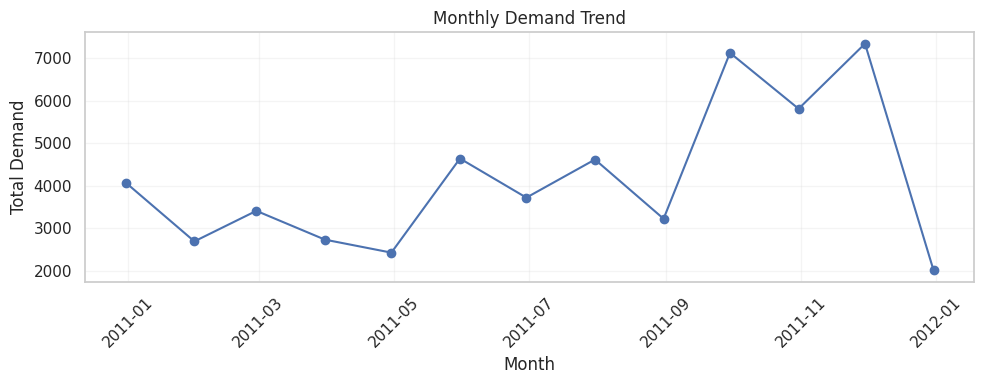

In [29]:
monthly = (
    week3.set_index("date")
    .resample("ME")["demand"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,4))
plt.plot(monthly["date"], monthly["demand"], marker="o")
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Report interpretation:** Higher-demand periods require stronger inventory readiness. Repeating patterns support the use of calendar variables in Week 4 forecasting.


## 4. Visual Analysis — Figure 2: Demand by Top Product Codes

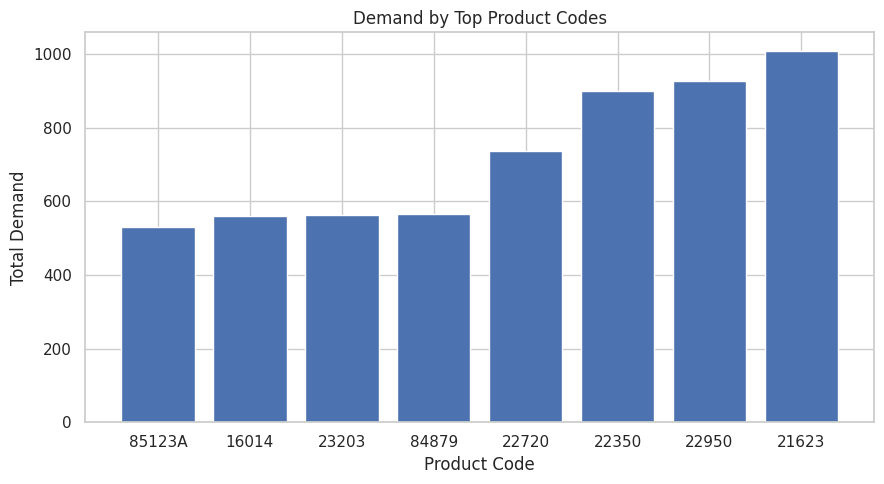

In [30]:
product_demand = (
    week3.groupby("stockcode")["demand"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .sort_values()
)

plt.figure(figsize=(9,5))
plt.bar(product_demand.index.astype(str), product_demand.values)
plt.title("Demand by Top Product Codes")
plt.xlabel("Product Code")
plt.ylabel("Total Demand")
plt.tight_layout()
plt.show()


**Report interpretation:** A smaller group of SKUs can contribute a disproportionate share of activity. These high-volume products should receive tighter monitoring and differentiated replenishment policies.


## 5. Visual Analysis — Figure 3: Distribution of Daily Product Demand

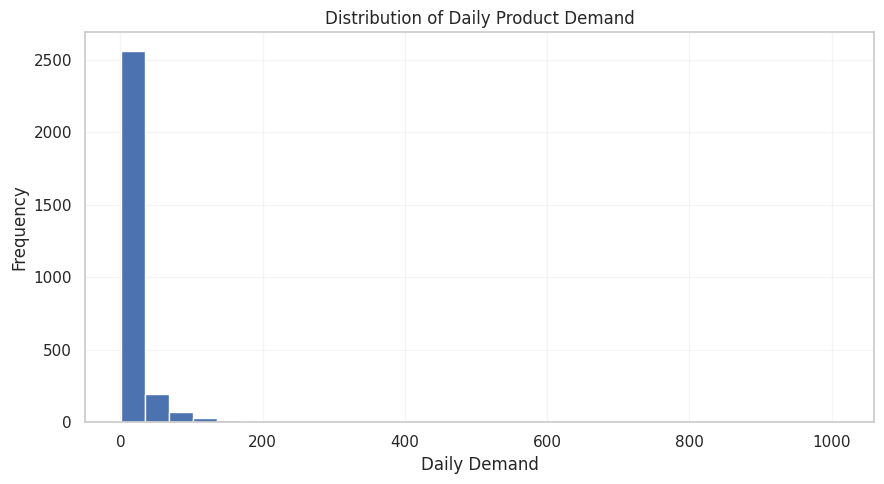

In [31]:
plt.figure(figsize=(9,5))
plt.hist(week3["demand"], bins=30)
plt.title("Distribution of Daily Product Demand")
plt.xlabel("Daily Demand")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Report interpretation:** A right-skewed demand distribution indicates a long upper tail. Peak demand should therefore be considered when defining safety stock and replenishment rules.


## 6. Visual Analysis — Figure 4: Demand vs Transportation Cost

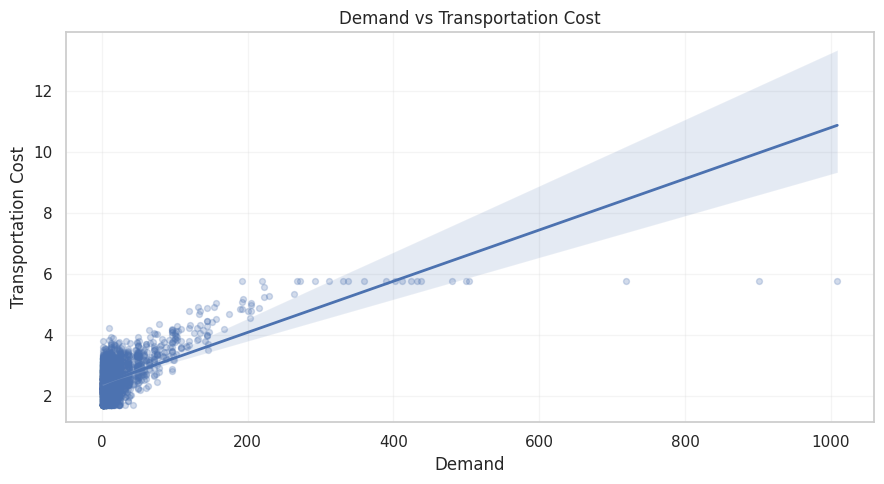

In [32]:
plt.figure(figsize=(9,5))
sns.regplot(
    data=week3,
    x="demand",
    y="transport_cost",
    scatter_kws={"alpha":0.25, "s":18},
    line_kws={"linewidth":2}
)
plt.title("Demand vs Transportation Cost")
plt.xlabel("Demand")
plt.ylabel("Transportation Cost")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Report interpretation:** The illustrative operational layer shows a positive association between demand volume and transportation cost, while the non-perfect relationship suggests other factors such as location, route conditions and consolidation also matter.


## 7. Visual Analysis — Figure 5: Average Demand by Day of Week

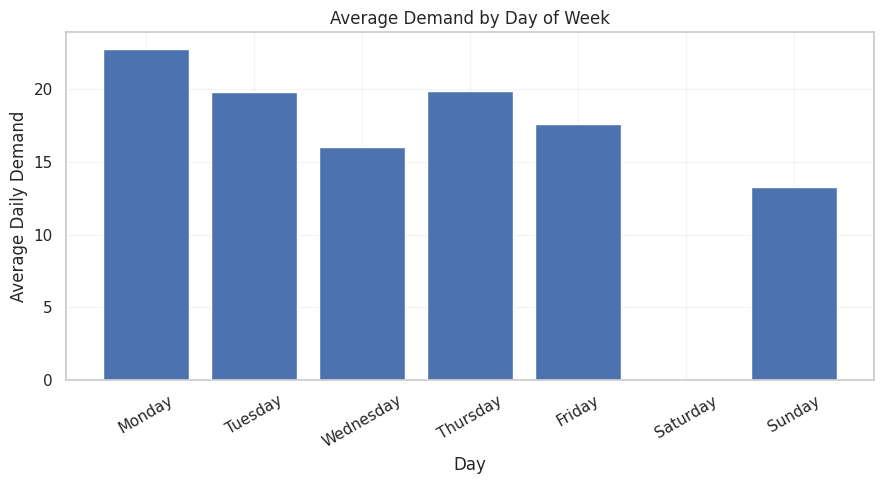

In [33]:
week3["day_name"] = week3["date"].dt.day_name()

day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

avg_demand_dow = (
    week3.groupby("day_name")["demand"]
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(9,5))
plt.bar(avg_demand_dow.index, avg_demand_dow.values)
plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Daily Demand")
plt.xticks(rotation=30)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Report interpretation:** Weekday differences justify calendar-aware planning for staffing, replenishment timing, order cut-offs and dispatch capacity.


## 8. Visual Analysis — Figure 6: Correlation Matrix of Key Logistics Variables

,demand,revenue,inventory_index,transport_cost,delivery_time
demand,1.00,0.76,0.82,0.65,0.53
revenue,0.76,1.00,0.44,0.36,0.32
inventory_index,0.82,0.44,1.00,0.68,0.53
transport_cost,0.65,0.36,0.68,1.00,0.40
delivery_time,0.53,0.32,0.53,0.40,1.00


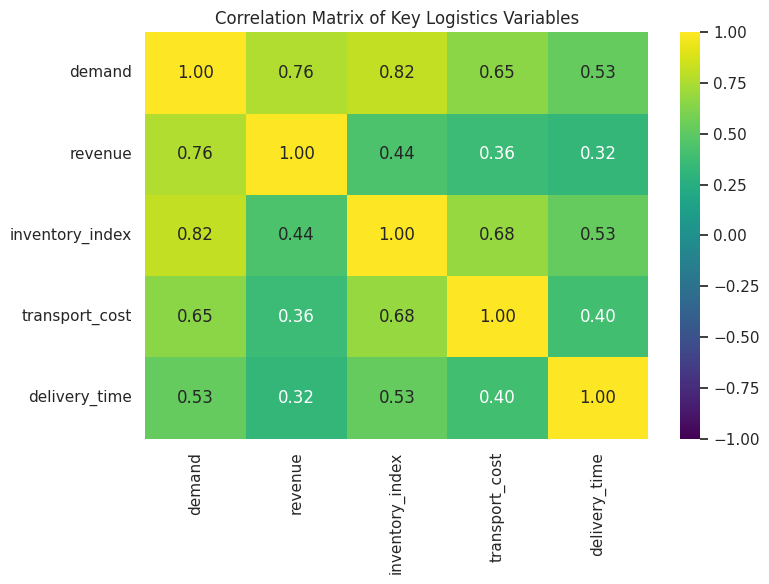

In [34]:
analysis_cols = [
    "demand", "revenue", "inventory_index",
    "transport_cost", "delivery_time"
]

correlation = week3[analysis_cols].corr()
display(correlation.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Matrix of Key Logistics Variables")
plt.tight_layout()
plt.show()


**Report interpretation:** Demand and revenue are strongly related because revenue is derived from quantity and price. Correlation is exploratory evidence only and must not be treated as proof of causation.


## 9. Visual Analysis — Figure 7: Warehouse Operational Comparison

,demand,avg_inventory_index,avg_delivery_time
warehouse,,,
WH-01,20211,165.48,2.17
WH-02,16596,166.84,2.15
WH-03,17010,177.92,2.18


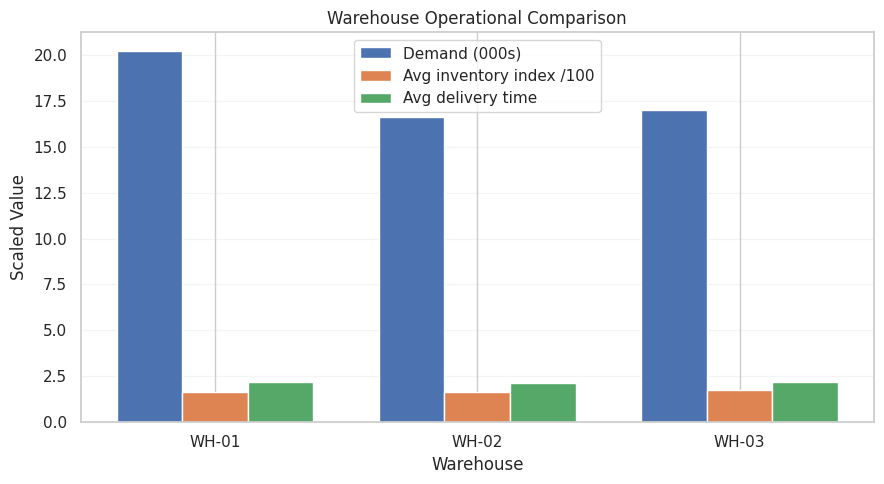

In [35]:
warehouse_summary = (
    week3.groupby("warehouse")
    .agg(
        demand=("demand","sum"),
        avg_inventory_index=("inventory_index","mean"),
        avg_delivery_time=("delivery_time","mean")
    )
    .reindex(warehouse_names)
)

display(warehouse_summary.round(2))

warehouse_plot = warehouse_summary.copy()
warehouse_plot["Demand (000s)"] = warehouse_plot["demand"] / 1000
warehouse_plot["Avg inventory index /100"] = (
    warehouse_plot["avg_inventory_index"] / 100
)
warehouse_plot["Avg delivery time"] = warehouse_plot["avg_delivery_time"]

x = np.arange(len(warehouse_plot))
width = 0.25

plt.figure(figsize=(9,5))
plt.bar(
    x-width,
    warehouse_plot["Demand (000s)"],
    width,
    label="Demand (000s)"
)
plt.bar(
    x,
    warehouse_plot["Avg inventory index /100"],
    width,
    label="Avg inventory index /100"
)
plt.bar(
    x+width,
    warehouse_plot["Avg delivery time"],
    width,
    label="Avg delivery time"
)

plt.title("Warehouse Operational Comparison")
plt.xlabel("Warehouse")
plt.ylabel("Scaled Value")
plt.xticks(x, warehouse_plot.index)
plt.legend()
plt.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.show()


**Report interpretation:** Warehouse-level differences can justify location-specific inventory thresholds and allocation policies. A high-demand warehouse with weaker inventory coverage may face greater stockout exposure, while excess inventory at a low-demand warehouse can increase holding cost.


## 10. Week 3 KPI View and Evidence Table

In [36]:
kpi_view = {
    "Total demand": week3["demand"].sum(),
    "Total revenue": week3["revenue"].sum(),
    "Average delivery time": week3["delivery_time"].mean(),
    "Average transport cost": week3["transport_cost"].mean(),
    "Average inventory index": week3["inventory_index"].mean()
}

display(pd.DataFrame(
    list(kpi_view.items()),
    columns=["Metric","Week 3 Value"]
).round(2))

highest_dow = avg_demand_dow.idxmax()
top_product = product_demand.idxmax()
highest_demand_warehouse = warehouse_summary["demand"].idxmax()

evidence = pd.DataFrame([
    ["Top-demand SKU", top_product, product_demand.max()],
    ["Highest average-demand day", highest_dow, avg_demand_dow.max()],
    ["Highest-demand warehouse", highest_demand_warehouse,
     warehouse_summary.loc[highest_demand_warehouse, "demand"]]
], columns=["Insight","Category","Value"])

display(evidence)


,Metric,Week 3 Value
0,Total demand,53817.00
1,Total revenue,115902.26
2,Average delivery time,2.16
3,Average transport cost,2.55
4,Average inventory index,169.15


,Insight,Category,Value
0,Top-demand SKU,21623,1009.000000
1,Highest average-demand day,Monday,22.785288
2,Highest-demand warehouse,WH-01,20211.000000


# Week 3 → Week 4 Handoff

The report-aligned EDA produces candidate predictors for Week 4:

- calendar/day-of-week features
- lagged demand
- rolling demand averages
- SKU-level demand concentration
- transportation cost
- inventory availability
- delivery time
- warehouse effects

Week 4 will use these findings to build and evaluate the demand-forecasting model and connect predictions to replenishment and resource-allocation decisions.


# ============================================================
# WEEK 4 — PREDICTIVE MODELING AND OPTIMIZATION
# ============================================================

This section is aligned directly with the Week 4 report.

## Prediction problem
Forecast next-period product-level daily demand using historical demand and operational features.

## Models
- Previous-week baseline
- Linear Regression
- Decision Tree Regression
- Random Forest Regression

## Validation
- Chronological train/test split
- TimeSeriesSplit
- GridSearchCV with time-aware folds
- MAE, RMSE, and R²

## Decision layer
- Forecast-based replenishment
- Constrained warehouse allocation using `scipy.optimize.linprog`

The operational variables used in the broader scenario are illustrative where the UCI dataset does not provide them directly.


## 7.1 Feature Engineering

The report specifies lag features, rolling statistics, calendar features, commercial variables, and operational variables where available. The core predictive implementation in the report uses lag, rolling, and calendar variables.


In [37]:
# Prepare the Week 2/3 daily demand table for forecasting
daily_demand = daily_demand.sort_values(["stockcode", "date"]).copy()
daily_demand["date"] = pd.to_datetime(daily_demand["date"], errors="coerce")

g = daily_demand.groupby("stockcode")["demand"]

daily_demand["lag_1"] = g.shift(1)
daily_demand["lag_7"] = g.shift(7)
daily_demand["lag_28"] = g.shift(28)

daily_demand["rolling_7"] = (
    daily_demand.groupby("stockcode")["demand"]
    .transform(lambda s: s.shift(1).rolling(7).mean())
)

daily_demand["rolling_28"] = (
    daily_demand.groupby("stockcode")["demand"]
    .transform(lambda s: s.shift(1).rolling(28).mean())
)

daily_demand["day_of_week"] = daily_demand["date"].dt.dayofweek
daily_demand["month"] = daily_demand["date"].dt.month
daily_demand["quarter"] = daily_demand["date"].dt.quarter
daily_demand["is_weekend"] = (daily_demand["day_of_week"] >= 5).astype(int)

display(daily_demand[["date","stockcode","demand","lag_1","lag_7","lag_28","rolling_7","rolling_28","day_of_week","month","quarter","is_weekend"]].head(15))


,date,stockcode,demand,lag_1,lag_7,lag_28,rolling_7,rolling_28,day_of_week,month,quarter,is_weekend
0,2010-12-01,10002,60,NaN,NaN,NaN,NaN,NaN,2,12,4,0
1340,2010-12-02,10002,1,60.0,NaN,NaN,NaN,NaN,3,12,4,0
2263,2010-12-03,10002,8,1.0,NaN,NaN,NaN,NaN,4,12,4,0
3396,2010-12-05,10002,1,8.0,NaN,NaN,NaN,NaN,6,12,4,1
4538,2010-12-06,10002,25,1.0,NaN,NaN,NaN,NaN,0,12,4,0
6009,2010-12-07,10002,8,25.0,NaN,NaN,NaN,NaN,1,12,4,0
7286,2010-12-08,10002,13,8.0,NaN,NaN,NaN,NaN,2,12,4,0
8486,2010-12-09,10002,44,13.0,60.0,NaN,16.571429,NaN,3,12,4,0
9744,2010-12-10,10002,48,44.0,1.0,NaN,14.285714,NaN,4,12,4,0
11808,2010-12-13,10002,27,48.0,8.0,NaN,21.000000,NaN,0,12,4,0


## 7.2 Time-Aware Train/Test Split

The report requires chronological validation to avoid leakage. Earlier observations are used for training and later observations for testing.


In [38]:
features = [
    "lag_1", "lag_7", "lag_28",
    "rolling_7", "rolling_28",
    "day_of_week", "month",
    "quarter", "is_weekend"
]

model_data = daily_demand.dropna(subset=features + ["demand"]).copy()
cutoff = model_data["date"].quantile(0.80)
train = model_data[model_data["date"] <= cutoff].copy()
test = model_data[model_data["date"] > cutoff].copy()
X_train, y_train = train[features], train["demand"]
X_test, y_test = test[features], test["demand"]

print("Cutoff date:", cutoff)
print("Training rows:", len(train))
print("Testing rows:", len(test))


Cutoff date: 2011-11-03 00:00:00
Training rows: 153259
Testing rows: 38012


## 7.3 Previous-Week Baseline

The report requires a simple previous-week baseline as the minimum performance benchmark.


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_pred = test["lag_7"].values
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline MAE : {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R²  : {baseline_r2:.3f}")


Baseline MAE : 23.98
Baseline RMSE: 75.66
Baseline R²  : -0.594


## 7.4 Train and Compare Models

This follows the Week 4 report exactly: Linear Regression, Decision Tree Regression (`max_depth=8`), and Random Forest Regression (`n_estimators=200`, `max_depth=12`).


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred_i = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred_i),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_i)),
        "R2": r2_score(y_test, pred_i)
    })

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
display(results_df.round(3))


,Model,MAE,RMSE,R2
0,Linear Regression,19.271,51.749,0.254
1,Decision Tree,19.591,74.802,-0.558
2,Random Forest,20.269,56.604,0.108


## 7.5 Time-Series Cross-Validation

The report uses `TimeSeriesSplit(n_splits=5)` to evaluate the Random Forest using chronological folds.


In [41]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)
rf = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
cv_mae = -cross_val_score(rf, model_data[features], model_data["demand"], cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)

print("Time-series CV MAE by split:", np.round(cv_mae, 3))
print("Mean CV MAE:", round(cv_mae.mean(), 3))


Time-series CV MAE by split: [20.138 18.523 15.506 21.64  21.009]
Mean CV MAE: 19.363


## 7.6 Hyperparameter Tuning

The report uses GridSearchCV with TimeSeriesSplit and the exact parameter grid below.


In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, None],
    "min_samples_leaf": [1, 3, 5]
}

search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)
print("Best CV MAE:", round(-search.best_score_, 3))


Best parameters: {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV MAE: 18.795


## 7.7 Forecast Evaluation

The tuned Random Forest is evaluated on the chronological test period using MAE, RMSE, and R².


In [43]:
best_model = search.best_estimator_
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")


MAE : 19.01
RMSE: 53.49
R²  : 0.203


## Additional Model Output — Actual vs Predicted Demand

The report lists the forecast series as an expected output. This additional visualization helps inspect the model's behavior on the held-out future period.


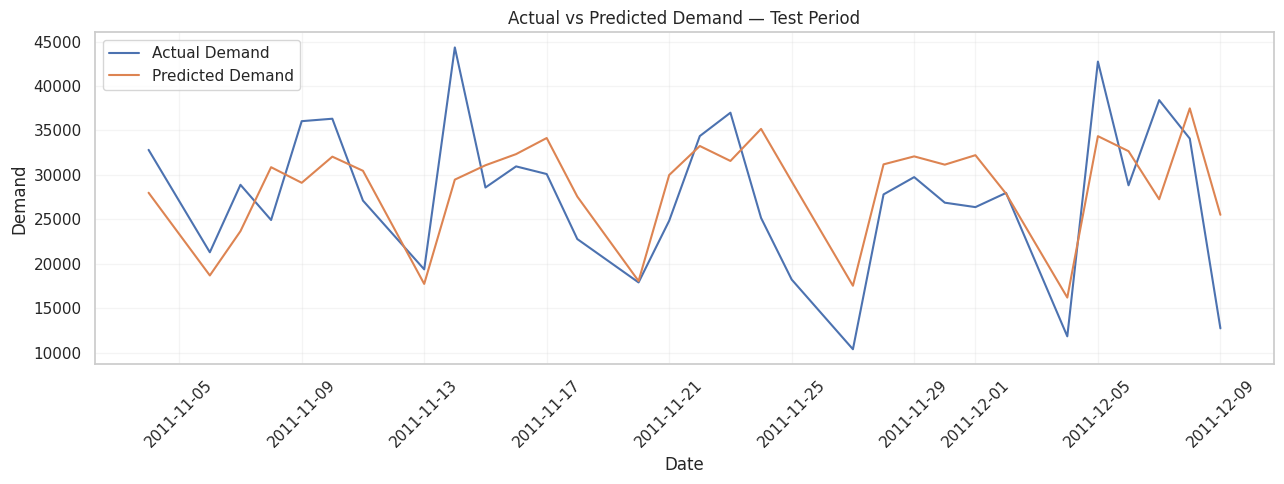

In [44]:
evaluation_df = test[["date", "stockcode", "demand"]].copy()
evaluation_df["prediction"] = pred
actual_by_date = evaluation_df.groupby("date")["demand"].sum()
pred_by_date = evaluation_df.groupby("date")["prediction"].sum()

plt.figure(figsize=(13,5))
plt.plot(actual_by_date.index, actual_by_date.values, label="Actual Demand")
plt.plot(pred_by_date.index, pred_by_date.values, label="Predicted Demand")
plt.title("Actual vs Predicted Demand — Test Period")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Additional Model Output — Random Forest Feature Importance

The report lists feature importance as an expected output. The following cells provide that output for the tuned Random Forest.


In [45]:
feature_importance = (
    pd.DataFrame({"Feature": features, "Importance": best_model.feature_importances_})
    .sort_values("Importance", ascending=False)
)
display(feature_importance.round(4))


,Feature,Importance
4,rolling_28,0.6839
3,rolling_7,0.0921
0,lag_1,0.0577
1,lag_7,0.0466
2,lag_28,0.0454
5,day_of_week,0.0335
6,month,0.0252
8,is_weekend,0.0106
7,quarter,0.0050


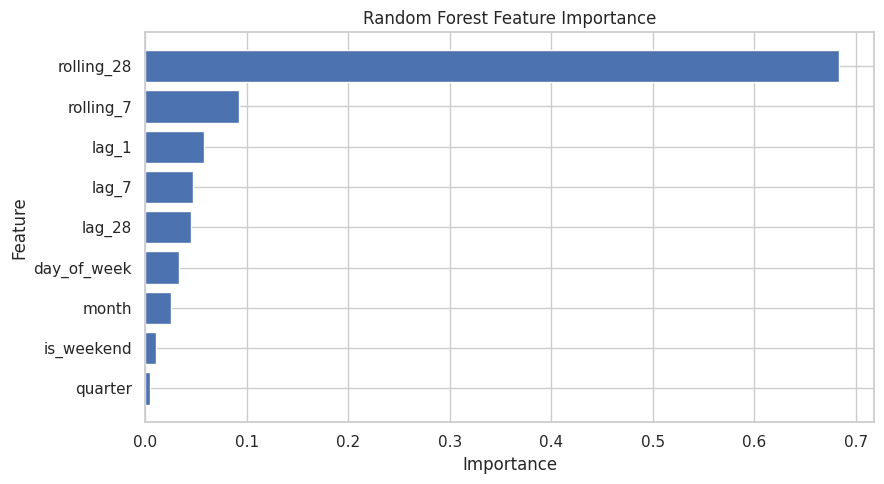

In [46]:
plt.figure(figsize=(9,5))
fi = feature_importance.sort_values("Importance")
plt.barh(fi["Feature"], fi["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 9.1 Replenishment Logic

The report defines:

**Reorder Quantity = max(0, Forecast Daily Demand × (Lead Time + Review Period) + Safety Stock − Current Inventory)**

Operational fields below are illustrative, as stated in the report.


In [47]:
# Forecast the latest available feature row per SKU
latest_rows = (
    model_data.sort_values(["stockcode", "date"])
    .groupby("stockcode", as_index=False)
    .tail(1)
    .copy()
)

latest_rows["forecast_daily_demand"] = best_model.predict(latest_rows[features])
rng = np.random.default_rng(42)
latest_rows["lead_time_days"] = rng.integers(3, 10, size=len(latest_rows))
latest_rows["review_period_days"] = 2
latest_rows["safety_stock"] = np.ceil(latest_rows["forecast_daily_demand"] * 0.25)
latest_rows["current_inventory"] = np.maximum(0, np.ceil(latest_rows["forecast_daily_demand"] * rng.uniform(1.0, 5.0, size=len(latest_rows))))
latest_rows["recommended_reorder_qty"] = np.maximum(0, (latest_rows["forecast_daily_demand"] * (latest_rows["lead_time_days"] + latest_rows["review_period_days"]) + latest_rows["safety_stock"] - latest_rows["current_inventory"]))

reorder_table = latest_rows[["stockcode","forecast_daily_demand","current_inventory","lead_time_days","safety_stock","recommended_reorder_qty"]].sort_values("recommended_reorder_qty", ascending=False)
display(reorder_table.head(20))


,stockcode,forecast_daily_demand,current_inventory,lead_time_days,safety_stock,recommended_reorder_qty
275070,16014,391.392164,478.0,9,98.0,3925.313799
275328,22086,332.950750,632.0,9,84.0,3114.458249
275382,22197,328.034380,371.0,7,83.0,2664.309418
275079,20668,341.842695,517.0,7,86.0,2645.584252
275979,84879,263.266648,359.0,8,66.0,2339.666477
275137,21137,251.276648,315.0,8,63.0,2260.766478
272498,21915,288.407479,844.0,8,73.0,2113.074792
275760,23203,269.988922,510.0,7,68.0,1987.900299
276092,85099B,214.883702,733.0,9,54.0,1684.720723
275660,22952,188.238458,446.0,9,48.0,1672.623040


## 9.2 Constrained Warehouse Allocation

The Week 4 report specifies three warehouses with the following illustrative inputs:

- Forecast demand: `[120, 95, 80]`
- Current inventory: `[60, 70, 35]`
- Safety stock: `[45, 35, 30]`
- Remaining capacity: `[120, 80, 90]`
- Unit transport/replenishment cost: `[2.0, 2.5, 3.0]`
- Available supply: `240`

The optimization minimizes transportation/replenishment cost while respecting minimum shipment and capacity bounds.


In [48]:
from scipy.optimize import linprog

forecast_demand = np.array([120,95,80], dtype=float)
current_inventory = np.array([60,70,35], dtype=float)
safety_stock = np.array([45,35,30], dtype=float)
capacity_remaining = np.array([120,80,90], dtype=float)
unit_transport_cost = np.array([2.0,2.5,3.0], dtype=float)

minimum_need = np.maximum(safety_stock + forecast_demand - current_inventory, 0)

print("Minimum required shipment:", minimum_need)
print("Total minimum required:", minimum_need.sum())


Minimum required shipment: [105.  60.  75.]
Total minimum required: 240.0


In [49]:
c = unit_transport_cost
available_supply = 240
A_ub = np.array([np.ones(3)])
b_ub = np.array([available_supply])

bounds = [(minimum_need[i], capacity_remaining[i]) for i in range(3)]

result = linprog(c=c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")

if result.success:
    allocation = pd.DataFrame({
        "Warehouse": ["WH-01","WH-02","WH-03"],
        "Recommended Shipment": result.x,
        "Unit Transport Cost": unit_transport_cost
    })
    allocation["Estimated Cost"] = allocation["Recommended Shipment"] * allocation["Unit Transport Cost"]
    print("\nOptimization successful.")
    display(allocation.round(2))
    print("Total recommended shipment:", round(result.x.sum(), 2))
    print("Minimum allocation cost:", round(result.fun, 2))
else:
    print("\nOptimization failed:")
    print(result.message)



Optimization successful.


,Warehouse,Recommended Shipment,Unit Transport Cost,Estimated Cost
0,WH-01,105.0,2.0,210.0
1,WH-02,60.0,2.5,150.0
2,WH-03,75.0,3.0,225.0


Total recommended shipment: 240.0
Minimum allocation cost: 585.0


## Week 4 — Expected Outputs and Business Use

The notebook now produces every technical output described in the Week 4 report:

- Baseline forecast
- Model comparison
- MAE, RMSE, and R²
- Time-series cross-validation
- Tuned Random Forest parameters
- Forecast evaluation
- Feature importance
- Forecast series
- Reorder quantities
- Warehouse allocation
- Estimated allocation cost

Model accuracy should be interpreted together with logistics KPIs and operational relevance, not in isolation.


In [50]:
final_comparison = pd.concat([
    pd.DataFrame([{
        "Model": "Previous-Week Baseline",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2
    }]),
    results_df
], ignore_index=True)

display(final_comparison.sort_values("MAE").round(3))


,Model,MAE,RMSE,R2
1,Linear Regression,19.271,51.749,0.254
2,Decision Tree,19.591,74.802,-0.558
3,Random Forest,20.269,56.604,0.108
0,Previous-Week Baseline,23.985,75.658,-0.594


# Week 4 — Final Handoff

**Week 1 → Strategic Planning**

**Week 2 → Data Preparation**

**Week 3 → EDA and Visualization**

**Week 4 → Prediction and Optimization**

The predictive model is used as a decision-support component rather than as an isolated machine-learning exercise. Forecast demand is connected to replenishment quantities and constrained warehouse allocation.
